In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import contextily as ctx

from netCDF4 import Dataset
import geopandas as gpd
from shapely.geometry import Point
from pyproj import CRS, Transformer

from scipy.interpolate import interp1d
from scipy.stats import linregress

from pymannkendall import original_test as mk_test

from utils import process_events


pd.options.mode.chained_assignment = None  # default='warn'

In [2]:
hydroDir = "/eos/jeodpp/data/projects/CLIMEX/CFRisks/CFRisks_data/"

In [3]:
NUTS3 = gpd.read_file(f"{hydroDir}/NUTS3/NUTS3_modified.shp")
NutVector = NUTS3['NUTS_ID'].tolist()

In [4]:
Hanze_flood = pd.read_csv(f"{hydroDir}/HANZE/HANZE_events.csv")
Hanze_flood_1980 = Hanze_flood[Hanze_flood['Year'] > 1980]
Hanze_flood_1980 = Hanze_flood_1980[Hanze_flood_1980['Type'] != "Coastal"]
list_of_word_vectors = [regions.split(';') for regions in Hanze_flood['Regions affected (v2021)']]

In [5]:
len(Hanze_flood_1980)

1349

In [6]:
fl_events = pd.read_csv(f"{hydroDir}/hazard_data/fl_nuts3_v1.csv", index_col=0)
fl_events['enddate'] = pd.to_datetime(fl_events['enddate'])
fl_events['stardate'] = fl_events['enddate'] - pd.to_timedelta(fl_events['duration'], unit='D')

In [7]:

grouped_events = fl_events.groupby('NUT').size().reset_index(name='floods')
grouped_events.rename(columns={'NUT': 'NUTS_ID'}, inplace=True)


In [8]:
NUTS3_2021 = gpd.read_file(f"{hydroDir}/NUTS3/Regions_v2021_simplified.shp")

floods_plot = NUTS3_2021.merge(
    grouped_events,
    left_on='Code',
    right_on='NUTS_ID',
    how='left'
)

# Replace 0 with NaN for transparency in the plot
floods_plot.loc[floods_plot['floods'] == 0, 'floods'] = np.nan


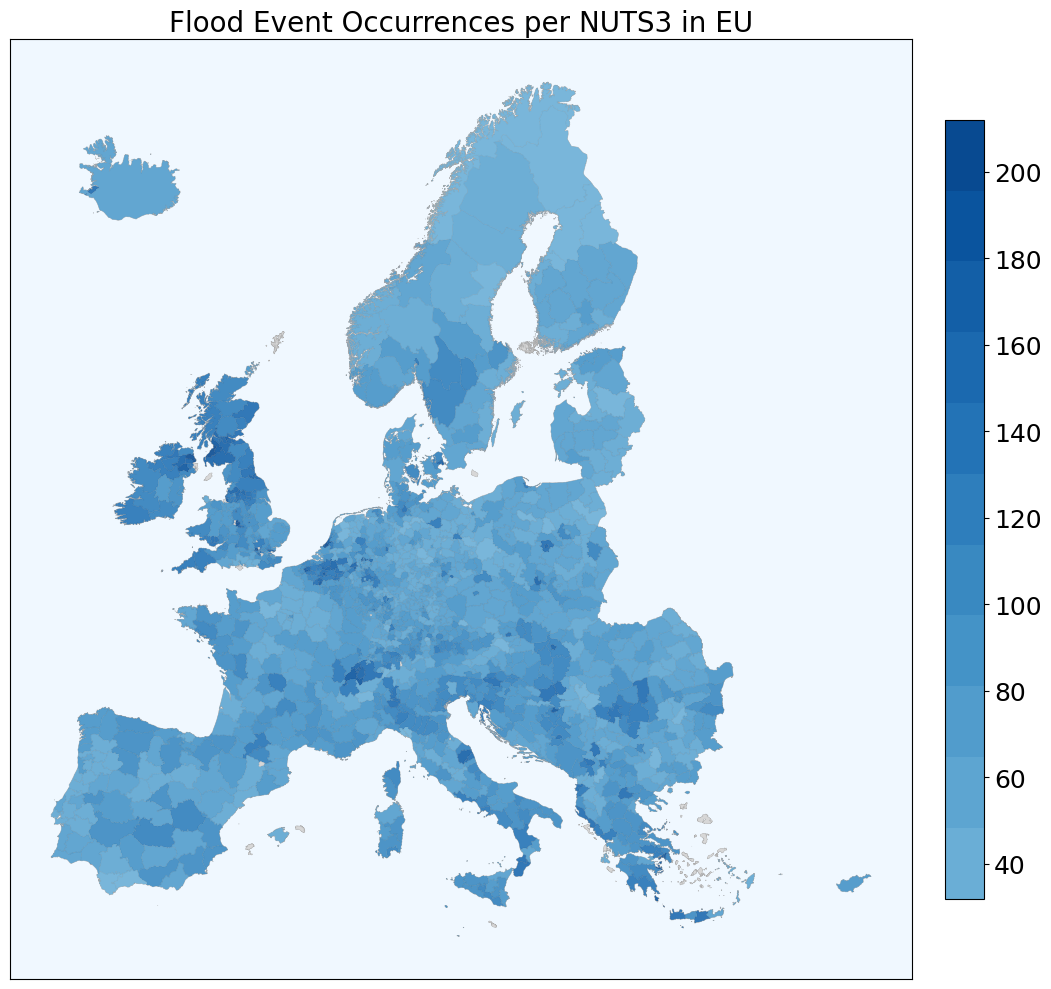

In [9]:


paletf = plt.cm.Blues(np.linspace(0.5, 0.9, 11))  # Start from a darker shade in the colormap
cmap = mcolors.ListedColormap(paletf)

# Plot setup
fig, ax = plt.subplots(figsize=(12, 10))

# Base map with subtle borders
NUTS3_2021.plot(ax=ax, facecolor='white', edgecolor='darkgrey', linewidth=0.5)


floods_plot.plot(
    ax=ax,
    column='floods',
    cmap=cmap,
    alpha=0.9,
    edgecolor='none',
    missing_kwds={'color': 'lightgrey'}
)

# Add a color bar
vmin = floods_plot['floods'].min(skipna=True)
vmax = floods_plot['floods'].max(skipna=True)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array(floods_plot['floods'])

cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.03)
#cbar.set_label("Number of Flood Events", fontsize=20)
cbar.ax.tick_params(labelsize=18)

# Aesthetics
ax.set_facecolor('aliceblue')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
plt.title("Flood Event Occurrences per NUTS3 in EU", fontsize=20)

plt.tight_layout()
plt.show()


In [10]:

IFlood = 56

# Three tested windows
short, medium, long = 14, 28, 56

windows = ["informed"]


list_POTh_large = []

for w in windows:
    wflood = IFlood
    df_POTh_large_w = pd.DataFrame()

    for NUTl in NutVector:
        # Subset events per region
        High_events = fl_events[fl_events["NUT"] == NUTl]
        if not High_events.empty:
            # Match Hanze rows for this NUT
            matches = [NUTl in vec for vec in list_of_word_vectors]
            tm = [i for i, val in enumerate(matches) if val]
            Hanze_Nut = Hanze_flood.iloc[tm]
            Hanze_Nut = Hanze_Nut[Hanze_Nut["Year"] > 1980].copy()
            Hanze_Nut["eid"] = Hanze_Nut["ID"]

            df_POTh_keep = pd.DataFrame()

            for e, eid in enumerate(Hanze_Nut["ID"]):
                # --- Flood sequence ---
                POTh_keep = process_events(
                    events_df=High_events,
                    reference_df=Hanze_Nut,
                    event_idx=e,
                    window=wflood,
                    nut_id=NUTl,
                    haz="flood",
                )
                df_POTh_keep = pd.concat([df_POTh_keep, POTh_keep], ignore_index=True)

            # Append region-level results
            df_POTh_large_w = pd.concat([df_POTh_large_w, df_POTh_keep], ignore_index=True)

    # Add NEID column per hazard
    for df in [df_POTh_large_w]:
        df["NEID"] = df["eventID"].astype(str) + df["NUTID"]

    list_POTh_large.append(df_POTh_large_w)


In [11]:
flood_match_results = list_POTh_large

In [12]:
len(flood_match_results[0])

2151

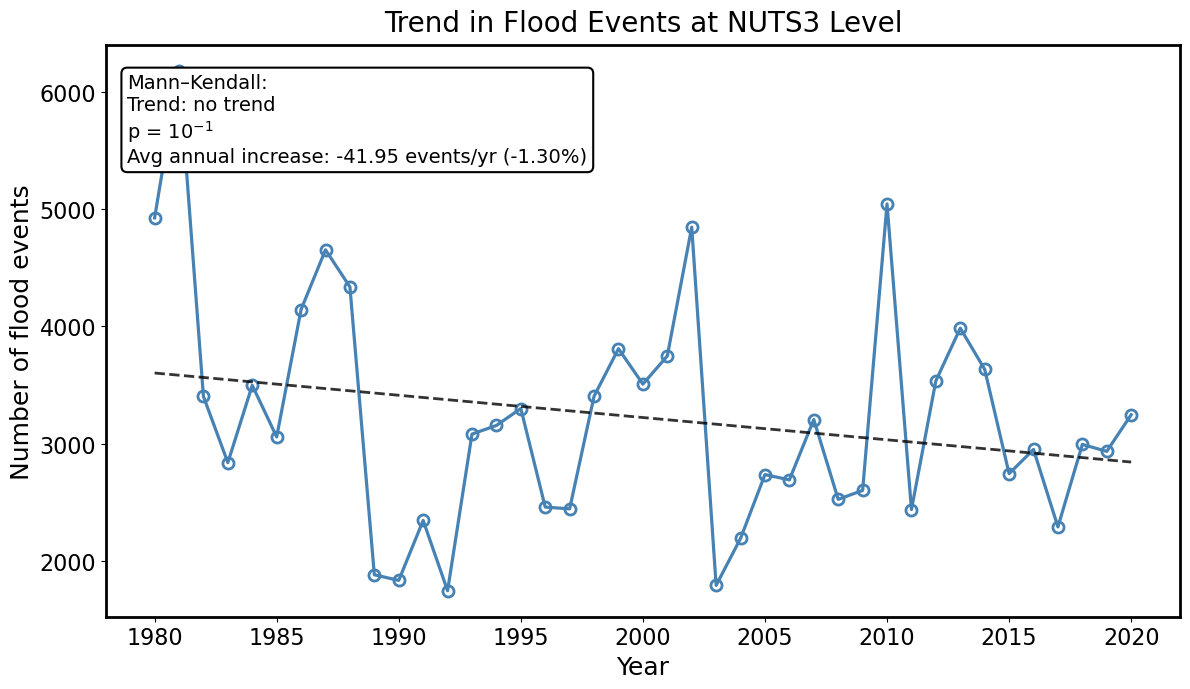

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pymannkendall import original_test as mk_test
from scipy.stats import linregress

# ---------------------------------------------------------
# 1) PREPARE DATA
# ---------------------------------------------------------

# Ensure stardate is datetime
fl_events["stardate"] = pd.to_datetime(fl_events["stardate"])

# Extract year
fl_events["year"] = fl_events["stardate"].dt.year

# Count events per year
events_per_year = (
    fl_events.groupby("year")
    .size()
    .reset_index(name="n_events")
)

# Sorted by year (important for trend calculations)
events_per_year = events_per_year.sort_values("year")

# ---------------------------------------------------------
# 2) TREND STATISTICS
# ---------------------------------------------------------

# Compute differences to get average annual increase
diffs = events_per_year["n_events"].diff().dropna()
avg_annual_increase = diffs.mean()

# Percent relative to mean number of yearly events
mean_events = events_per_year["n_events"].mean()
annual_pct_change = (avg_annual_increase / mean_events) * 100

# Mann–Kendall monotonic trend test
mk_result = mk_test(events_per_year["n_events"])

trend_txt = "increasing" if mk_result.trend == "increasing" else \
            "decreasing" if mk_result.trend == "decreasing" else "no trend"

def format_p_scientific(p):
    if p == 0:
        return r"$10^{-300}$"
    exponent = int(np.floor(np.log10(p)))
    return fr"$10^{{{exponent}}}$"

p_formatted = format_p_scientific(mk_result.p)

# ---------------------------------------------------------
# 3) FITTED LINE (simple linear regression)
# ---------------------------------------------------------

years = events_per_year["year"].values
counts = events_per_year["n_events"].values

slope, intercept, r_value, p_lin, stderr = linregress(years, counts)
trendline = intercept + slope * years

# ---------------------------------------------------------
# 4) PLOT
# ---------------------------------------------------------

plt.figure(figsize=(12, 7))

# Main line
plt.plot(
    years,
    counts,
    marker="o",
    markersize=8,
    markerfacecolor="none",
    markeredgewidth=2.0,
    markeredgecolor="steelblue", 
    linewidth=2.3,
    color="steelblue",
)

# Fitted trendline (black dashed)
plt.plot(
    years,
    trendline,
    linestyle="--",
    linewidth=2,
    color="black",
    alpha=0.8,
)

# Labels
plt.xlabel("Year", fontsize=18)
plt.ylabel("Number of flood events", fontsize=18)
plt.title("Trend in Flood Events at NUTS3 Level", fontsize=20, pad=10)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Thicker axis spines
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

# ---------------------------------------------------------
# 5) ANNOTATION BOX
# ---------------------------------------------------------

annotation = (
    "Mann–Kendall:\n"
    f"Trend: {trend_txt}\n"
    f"p = {p_formatted}\n"
    f"Avg annual increase: {avg_annual_increase:.2f} events/yr "
    f"({annual_pct_change:.2f}%)"
)

plt.text(
    0.02, 0.95, annotation,
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black",
        linewidth=1.5
    )
)

plt.tight_layout()
plt.show()



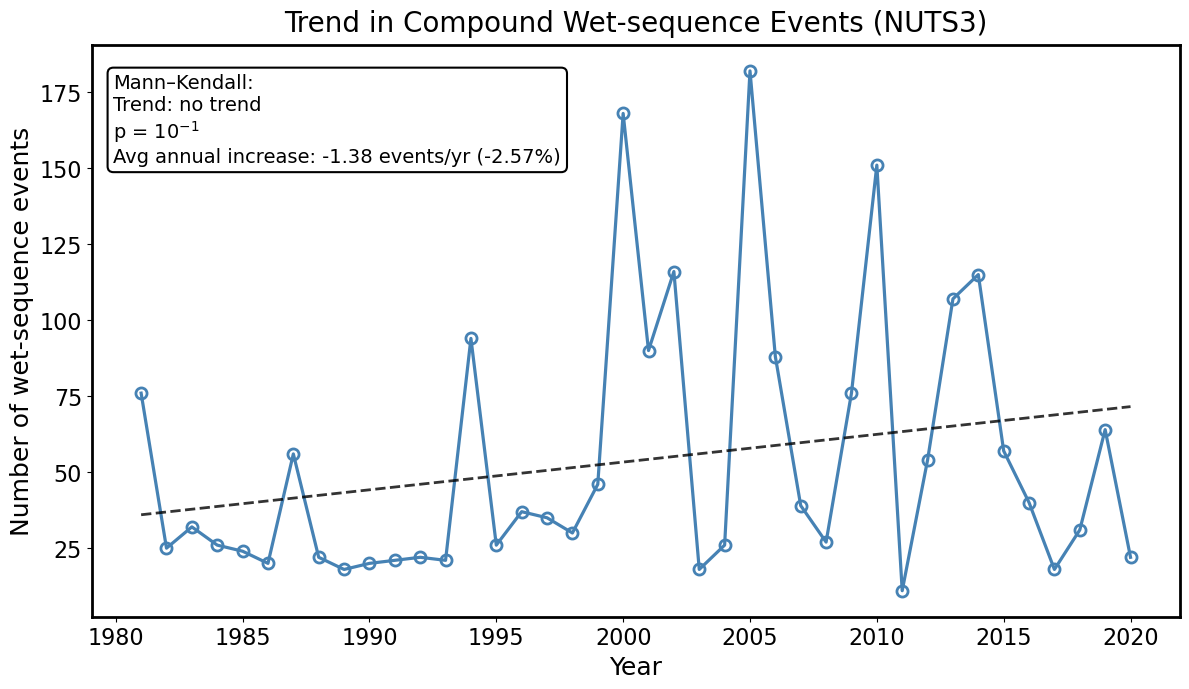

In [14]:

# ---------------------------------------------------------
# 1) PREPARE DATA
# ---------------------------------------------------------

df = flood_match_results[0].copy()

# Ensure stardate is datetime
df["stardate"] = pd.to_datetime(df["stardate"])

# Extract year
df["year"] = df["stardate"].dt.year

# Count events per year
events_per_year = (
    df.groupby("year")
      .size()
      .reset_index(name="n_events")
      .sort_values("year")
)

# ---------------------------------------------------------
# 2) TREND STATISTICS
# ---------------------------------------------------------

# Average annual increase (simple diff)
diffs = events_per_year["n_events"].diff().dropna()
avg_annual_increase = diffs.mean()

# Percent increase relative to mean
mean_events = events_per_year["n_events"].mean()
annual_pct_change = (avg_annual_increase / mean_events) * 100

# Mann–Kendall test
mk_result = mk_test(events_per_year["n_events"])

trend_txt = (
    "increasing" if mk_result.trend == "increasing"
    else "decreasing" if mk_result.trend == "decreasing"
    else "no trend"
)

# p-value as 10^{-x}
def format_p_scientific(p):
    if p == 0:
        return r"$10^{-300}$"
    exponent = int(np.floor(np.log10(p)))
    return fr"$10^{{{exponent}}}$"

p_formatted = format_p_scientific(mk_result.p)

# ---------------------------------------------------------
# 3) FIT LINEAR TREND
# ---------------------------------------------------------

years = events_per_year["year"].values
counts = events_per_year["n_events"].values

slope, intercept, rvalue, p_lin, stderr = linregress(years, counts)
trendline = intercept + slope * years

# ---------------------------------------------------------
# 4) PLOT
# ---------------------------------------------------------

plt.figure(figsize=(12, 7))

# Main line
plt.plot(
    years, counts,
    marker="o",
    markersize=8,
    markerfacecolor="none",
    markeredgewidth=2,
    markeredgecolor="steelblue",
    linewidth=2.3,
    color="steelblue"
)

# Trendline
plt.plot(
    years, trendline,
    linestyle="--",
    linewidth=2,
    color="black",
    alpha=0.8
)

# Labels
plt.xlabel("Year", fontsize=18)
plt.ylabel("Number of wet-sequence events", fontsize=18)
plt.title("Trend in Compound Wet-sequence Events (NUTS3)", fontsize=20, pad=10)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Thicker borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(2)

# ---------------------------------------------------------
# 5) ANNOTATION BOX
# ---------------------------------------------------------

annotation = (
    "Mann–Kendall:\n"
    f"Trend: {trend_txt}\n"
    f"p = {p_formatted}\n"
    f"Avg annual increase: {avg_annual_increase:.2f} events/yr "
    f"({annual_pct_change:.2f}%)"
)

plt.text(
    0.02, 0.95, annotation,
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor="black",
        linewidth=1.5
    )
)

plt.tight_layout()
plt.show()


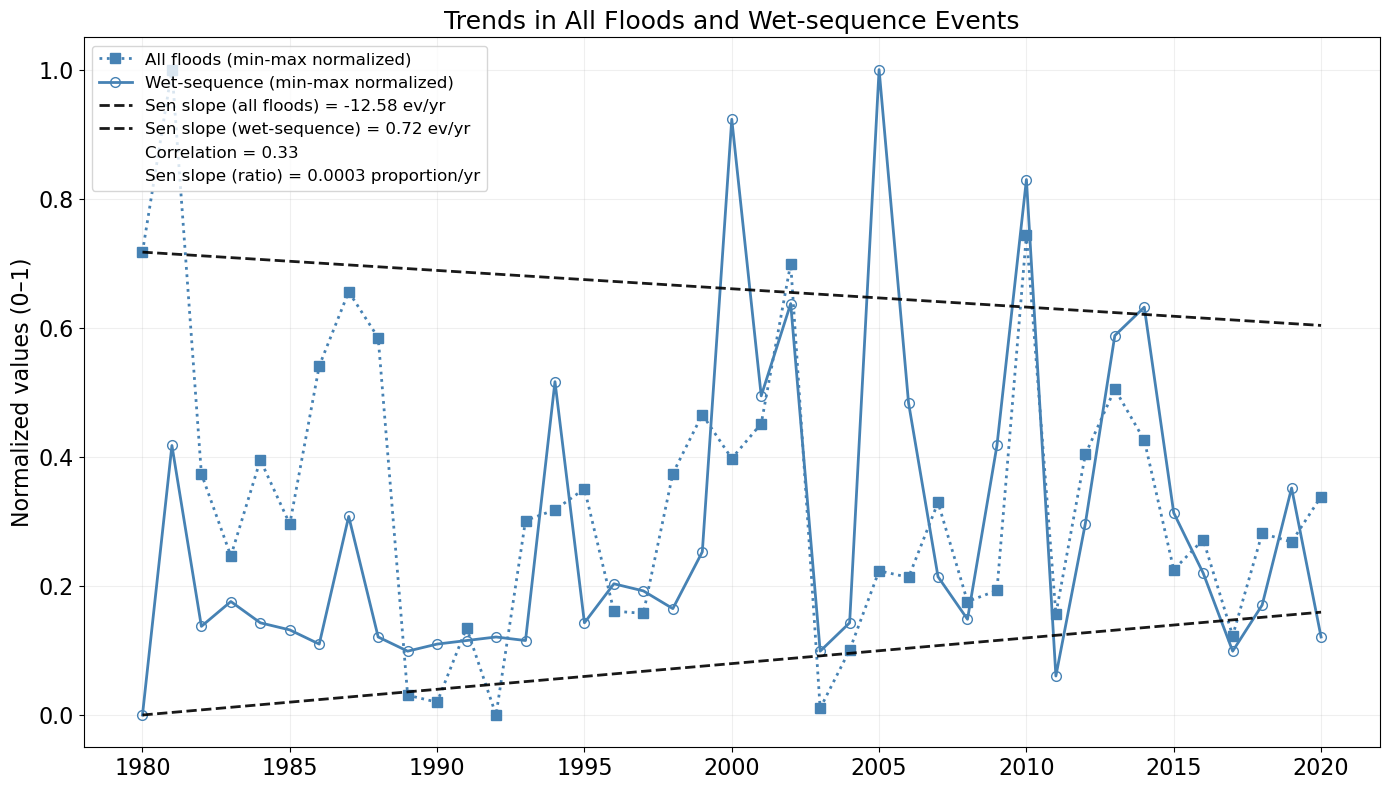

Floods MK Test: Mann_Kendall_Test(trend='no trend', h=False, p=0.41225516799167616, z=-0.8199314829115114, Tau=-0.09024390243902439, s=-74.0, var_s=7926.666666666667, slope=-12.584324324324324, intercept=3332.6864864864865)
Compound MK Test: Mann_Kendall_Test(trend='increasing', h=True, p=0.04418887482753964, z=2.012294756710459, Tau=0.21951219512195122, s=180.0, var_s=7912.666666666667, slope=0.725, intercept=17.5)
Proportion MK Test: Mann_Kendall_Test(trend='increasing', h=True, p=0.011498056471976659, z=2.527186077466987, Tau=0.275609756097561, s=226.0, var_s=7926.666666666667, slope=0.0002703739188111378, intercept=0.006630354813803039)
Correlation between Floods and Compound Events: 0.33


In [15]:

df_fl = fl_events.copy()
df_compound = flood_match_results[0].copy()

df_fl["year"] = pd.to_datetime(df_fl["stardate"]).dt.year
df_compound["year"] = pd.to_datetime(df_compound["stardate"]).dt.year

fl_yearly = df_fl.groupby("year").size().reset_index(name="flood_count")
compound_yearly = df_compound.groupby("year").size().reset_index(name="compound_count")

df_years = pd.merge(fl_yearly, compound_yearly, on="year", how="left").fillna(0)
df_years = df_years.sort_values("year").reset_index(drop=True)

years = df_years["year"].values
D = df_years["flood_count"].values.astype(float)
C = df_years["compound_count"].values.astype(float)

# Mann-Kendall + Sen slope (original counts)
mk_D = mk_test(D)
mk_C = mk_test(C)

slope_D = mk_D.slope   # events per year (Sen)
slope_C = mk_C.slope

# Calculate proportions and perform MK test on proportions
mask = D > 0
p = (C[mask] / D[mask]).astype(float)
years_p = years[mask]

mk_p = mk_test(p)
slope_p = mk_p.slope

# Correlation between D and C
correlation = np.corrcoef(D, C)[0, 1]

# MIN-MAX normalization for plotting
def minmax_scale(x):
    x_min, x_max = x.min(), x.max()
    if x_max == x_min:
        return np.zeros_like(x), x_min, x_max
    return (x - x_min) / (x_max - x_min), x_min, x_max

D_norm, D_min, D_max = minmax_scale(D)
C_norm, C_min, C_max = minmax_scale(C)

# Rescale Sen slopes to normalized units for plotting trendlines
slope_D_norm = slope_D / (D_max - D_min) if (D_max - D_min) != 0 else 0.0
slope_C_norm = slope_C / (C_max - C_min) if (C_max - C_min) != 0 else 0.0

trend_D_norm = slope_D_norm * (years - years.min()) + D_norm[0]
trend_C_norm = slope_C_norm * (years - years.min()) + C_norm[0]

# Plot
plt.figure(figsize=(14, 8))

plt.plot(years, D_norm, marker="s", markersize=7, label="All floods (min-max normalized)", linewidth=2,
         markerfacecolor="steelblue", markeredgecolor="steelblue", linestyle=":", color="steelblue")
plt.plot(years, C_norm, marker="o", markersize=7, label="Wet-sequence (min-max normalized)",
         linewidth=2, markerfacecolor="none", markeredgecolor="steelblue", color="steelblue")

# Trendlines (black dashed)
plt.plot(years, trend_D_norm, linestyle="--", color="black", linewidth=2, alpha=0.9,
         label=f"Sen slope (all floods) = {slope_D:.2f} ev/yr")
plt.plot(years, trend_C_norm, linestyle="--", color="black", linewidth=2, alpha=0.9,
         label=f"Sen slope (wet-sequence) = {slope_C:.2f} ev/yr")

# Add correlation and Sen slope of ratio to the legend
plt.plot([], [], ' ', label=f"Correlation = {correlation:.2f}")
plt.plot([], [], ' ', label=f"Sen slope (ratio) = {slope_p:.4f} proportion/yr")

plt.xlabel("", fontsize=16)
plt.ylabel("Normalized values (0–1)", fontsize=16)
plt.title("Trends in All Floods and Wet-sequence Events", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tick_params(axis='both', labelsize=16)

plt.grid(alpha=0.2)
plt.legend(fontsize=12, loc="upper left")

plt.tight_layout()
plt.show()

# Print analysis results
print(f"Floods MK Test: {mk_D}")
print(f"Compound MK Test: {mk_C}")
print(f"Proportion MK Test: {mk_p}")
print(f"Correlation between Floods and Compound Events: {correlation:.2f}")

